<a href="https://colab.research.google.com/github/lariza-amoros/caldero-verde/blob/main/stock_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Can Machine Learning Beat the Stock Market?

## Project 2: Regression and Classification

### Objective
Evaluate whether Random Forest and XGBoost can predict
future stock returns and market risk, and whether
machine learning investment strategies can outperform
the S&P 500 (SPY) benchmark.

### Algorithms
- Random Forest Regressor
- XGBoost Regressor
- Random Forest Classifier
- XGBoost Classifier

### Data Period
January 2015 – December 2025

### Additional Experiment
Evaluate whether macroeconomic indicators and
historical market events improve predictive performance.

In [1]:
%pip install -q yfinance xgboost scikit-learn seaborn

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data
import yfinance as yf

# Machine Learning
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from xgboost import XGBRegressor, XGBClassifier

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

In [3]:
# Selected stocks
stocks = [
    "AAPL", "MSFT", "NVDA", "AMZN",
    "GOOGL", "JPM", "XOM", "JNJ"
]

# Benchmark and volatility index
benchmark = "SPY"
volatility_index = "^VIX"

# Complete ticker list
tickers = stocks + [benchmark, volatility_index]

# Historical period
start_date = "2015-01-01"
end_date = "2026-01-01"

print("Selected stocks:", stocks)
print("Benchmark:", benchmark)
print("Volatility Index:", volatility_index)

Selected stocks: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'JPM', 'XOM', 'JNJ']
Benchmark: SPY
Volatility Index: ^VIX


In [4]:
# Download historical financial data
raw_data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    group_by="column",
    progress=False,
    threads=True
)

# Display first rows
display(raw_data.head())

Price           Close                                                       \
Ticker           AAPL     AMZN      GOOGL        JNJ        JPM       MSFT   
Date                                                                         
2015-01-02  24.171759  15.4260  26.227924  75.737366  45.838097  39.607185   
2015-01-05  23.490801  15.1095  25.728178  75.208420  44.415054  39.242958   
2015-01-06  23.493010  14.7645  25.093222  74.838860  43.263424  38.666985   
2015-01-07  23.822432  14.9210  25.019423  76.490967  43.329430  39.158241   
2015-01-08  24.737747  15.0230  25.106598  77.092422  44.297688  40.310207   

Price                                                   ...     Volume  \
Ticker          NVDA         SPY        XOM       ^VIX  ...       AAPL   
Date                                                    ...              
2015-01-02  0.481884  169.267563  56.777924  17.790001  ...  212818400   
2015-01-05  0.473745  166.210617  55.224358  19.920000  ...  257142000   
2015-01-06  0.459381  164.645065  54.930771  21.120001  ...  263188400   
2015-01-07  0.458184  166.696747  55.487381  19.309999  ...  160423600   
2015-01-08  0.475420  169.654877  56.410927  17.010000  ...  237458000   

Price                                                                   \
Ticker          AMZN     GOOGL      JNJ       JPM      MSFT       NVDA   
Date                                                                     
2015-01-02  55664000  26480000  5753600  12600000  27913900  113680000   
2015-01-05  55484000  41182000  8079300  20100600  39673900  197952000   
2015-01-06  70380000  54456000  7428000  29074100  36447900  197764000   
2015-01-07  52806000  46918000  7931700  23843200  29114100  321808000   
2015-01-08  61768000  73054000  9916000  16971100  29645200  283780000   

Price                                 
Ticker            SPY       XOM ^VIX  
Date                                  
2015-01-02  121465900  10220400    0  
2015-01-05  169632600  18502400    0  
2015-01-06  209151400  16670700    0  
2015-01-07  125346700  13590700    0  
2015-01-08  147217800  15487500    0  

[5 rows x 50 columns]

In [5]:
# Dataset dimensions
print("Dataset shape:", raw_data.shape)

# Date coverage
print("Start date:", raw_data.index.min())
print("End date:", raw_data.index.max())

# Missing values
print("\nMissing values:")
display(raw_data.isnull().sum())

# Dataset structure
print("\nDataset information:")
raw_data.info()

Dataset shape: (2766, 50)
Start date: 2015-01-02 00:00:00
End date: 2025-12-31 00:00:00

Missing values:


Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        JNJ       0
        JPM       0
        MSFT      0
        NVDA      0
        SPY       0
        XOM       0
        ^VIX      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        JNJ       0
        JPM       0
        MSFT      0
        NVDA      0
        SPY       0
        XOM       0
        ^VIX      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        JNJ       0
        JPM       0
        MSFT      0
        NVDA      0
        SPY       0
        XOM       0
        ^VIX      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        JNJ       0
        JPM       0
        MSFT      0
        NVDA      0
        SPY       0
        XOM       0
        ^VIX      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        JNJ       0
        JPM       0
        MSFT      0
        NVDA      0
        SPY       0
        XOM       0
        ^VIX      0
dtype: int64


Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    2766 non-null   float64
 1   (Close, AMZN)    2766 non-null   float64
 2   (Close, GOOGL)   2766 non-null   float64
 3   (Close, JNJ)     2766 non-null   float64
 4   (Close, JPM)     2766 non-null   float64
 5   (Close, MSFT)    2766 non-null   float64
 6   (Close, NVDA)    2766 non-null   float64
 7   (Close, SPY)     2766 non-null   float64
 8   (Close, XOM)     2766 non-null   float64
 9   (Close, ^VIX)    2766 non-null   float64
 10  (High, AAPL)     2766 non-null   float64
 11  (High, AMZN)     2766 non-null   float64
 12  (High, GOOGL)    2766 non-null   float64
 13  (High, JNJ)      2766 non-null   float64
 14  (High, JPM)      2766 non-null   float64
 15  (High, MSFT)     2766 non-null   float64
 16  (High, NVDA)     276

In [6]:
# Extract adjusted closing prices
close_prices = raw_data["Close"].copy()

# Organize columns
close_prices = close_prices.reindex(columns=tickers)

# Preview
display(close_prices.head())

Ticker,AAPL,MSFT,NVDA,AMZN,GOOGL,JPM,XOM,JNJ,SPY,^VIX
Date,,,,,,,,,,
2015-01-02,24.171759,39.607185,0.481884,15.4260,26.227924,45.838097,56.777924,75.737366,169.267563,17.790001
2015-01-05,23.490801,39.242958,0.473745,15.1095,25.728178,44.415054,55.224358,75.208420,166.210617,19.920000
2015-01-06,23.493010,38.666985,0.459381,14.7645,25.093222,43.263424,54.930771,74.838860,164.645065,21.120001
2015-01-07,23.822432,39.158241,0.458184,14.9210,25.019423,43.329430,55.487381,76.490967,166.696747,19.309999
2015-01-08,24.737747,40.310207,0.475420,15.0230,25.106598,44.297688,56.410927,77.092422,169.654877,17.010000


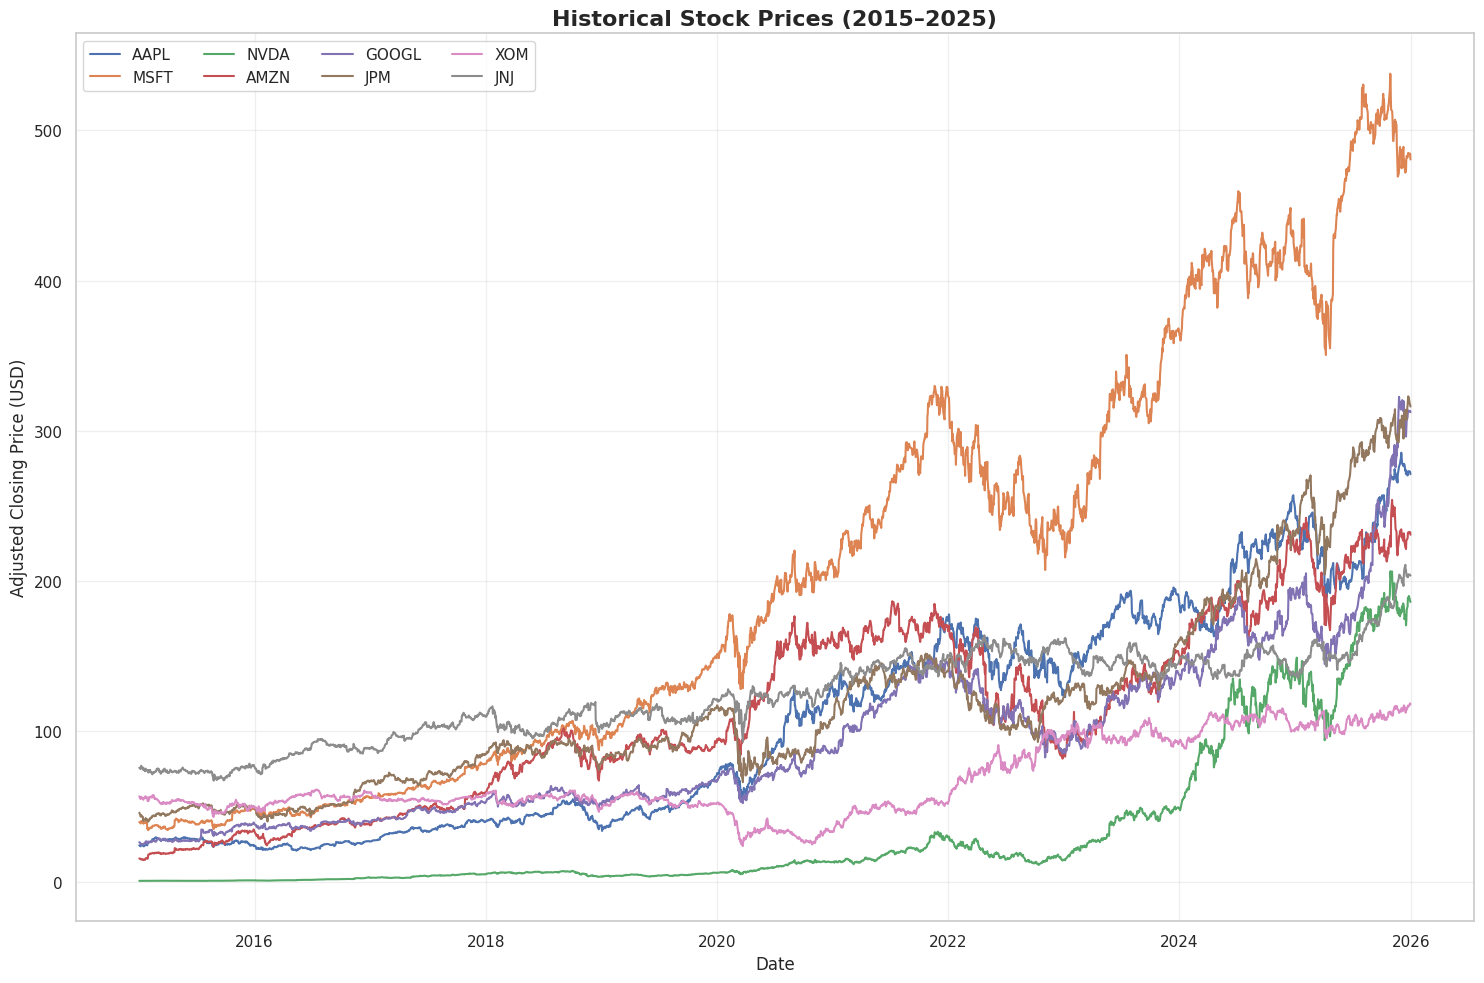

In [8]:
# PLottinig
plt.figure(figsize=(15, 10))

for stock in stocks:
    plt.plot(
        close_prices.index,
        close_prices[stock],
        label=stock,
        linewidth=1.5
    )

plt.title(
    "Historical Stock Prices (2015–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price (USD)")
plt.legend(ncol=4)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Calculate daily percentage returns
daily_returns = close_prices[stocks + ["SPY"]].pct_change()

# Remove first row with missing returns
daily_returns = daily_returns.dropna()

# Preview daily returns
display(daily_returns.head())

# Verify missing values
print("Missing values:", daily_returns.isnull().sum().sum())

Ticker,AAPL,MSFT,NVDA,AMZN,GOOGL,JPM,XOM,JNJ,SPY
Date,,,,,,,,,
2015-01-05,-0.028172,-0.009196,-0.016891,-0.020517,-0.019054,-0.031045,-0.027362,-0.006984,-0.018060
2015-01-06,0.000094,-0.014677,-0.030318,-0.022833,-0.024679,-0.025929,-0.005316,-0.004914,-0.009419
2015-01-07,0.014022,0.012705,-0.002606,0.010600,-0.002941,0.001526,0.010133,0.022076,0.012461
2015-01-08,0.038422,0.029418,0.037618,0.006836,0.003484,0.022346,0.016644,0.007863,0.017746
2015-01-09,0.001072,-0.008405,0.004028,-0.011749,-0.012211,-0.017387,-0.001409,-0.013630,-0.008014


Missing values: 0


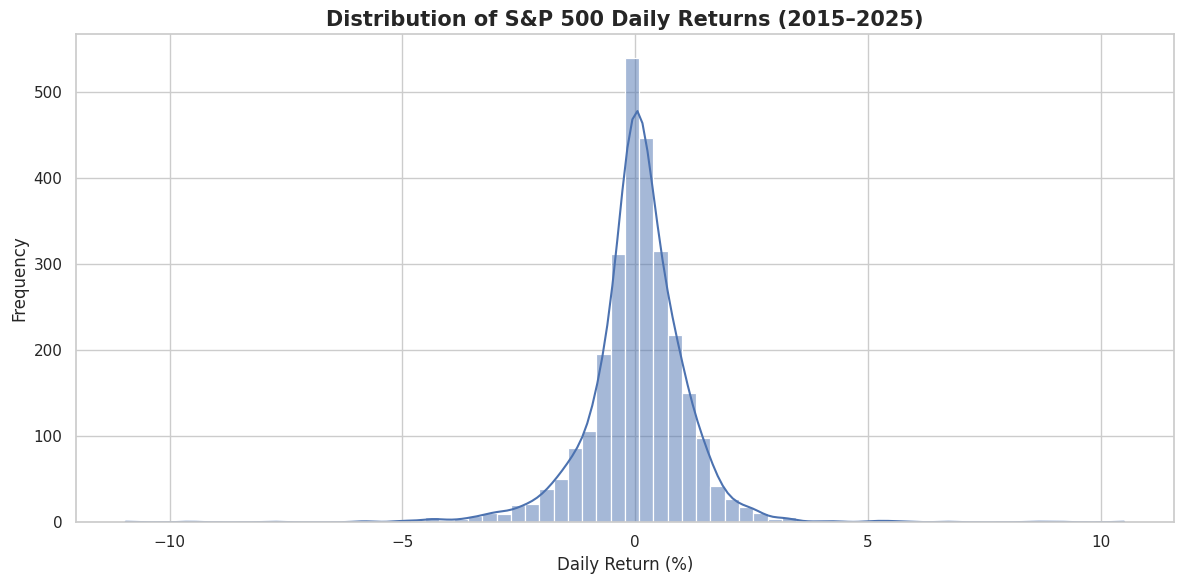

In [10]:
plt.figure(figsize=(12, 6))

sns.histplot(
    daily_returns["SPY"] * 100,
    bins=70,
    kde=True
)

plt.title(
    "Distribution of S&P 500 Daily Returns (2015–2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

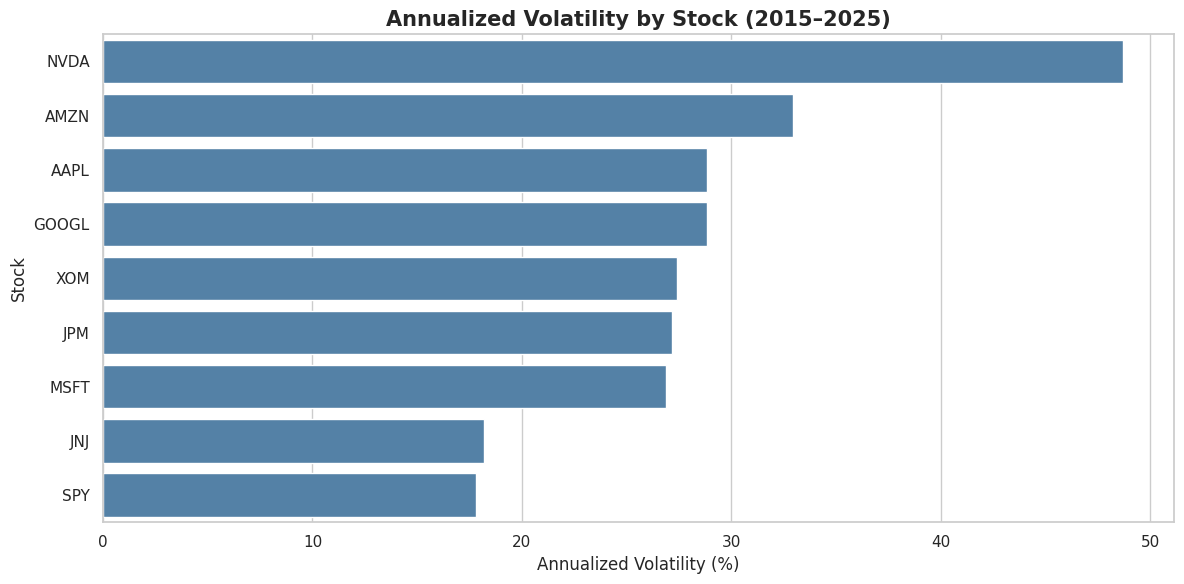

In [11]:
# Annualized volatility
annual_volatility = (
    daily_returns.std() * np.sqrt(252) * 100
)

annual_volatility = annual_volatility.sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=annual_volatility.values,
    y=annual_volatility.index,
    color="steelblue"
)

plt.title(
    "Annualized Volatility by Stock (2015–2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

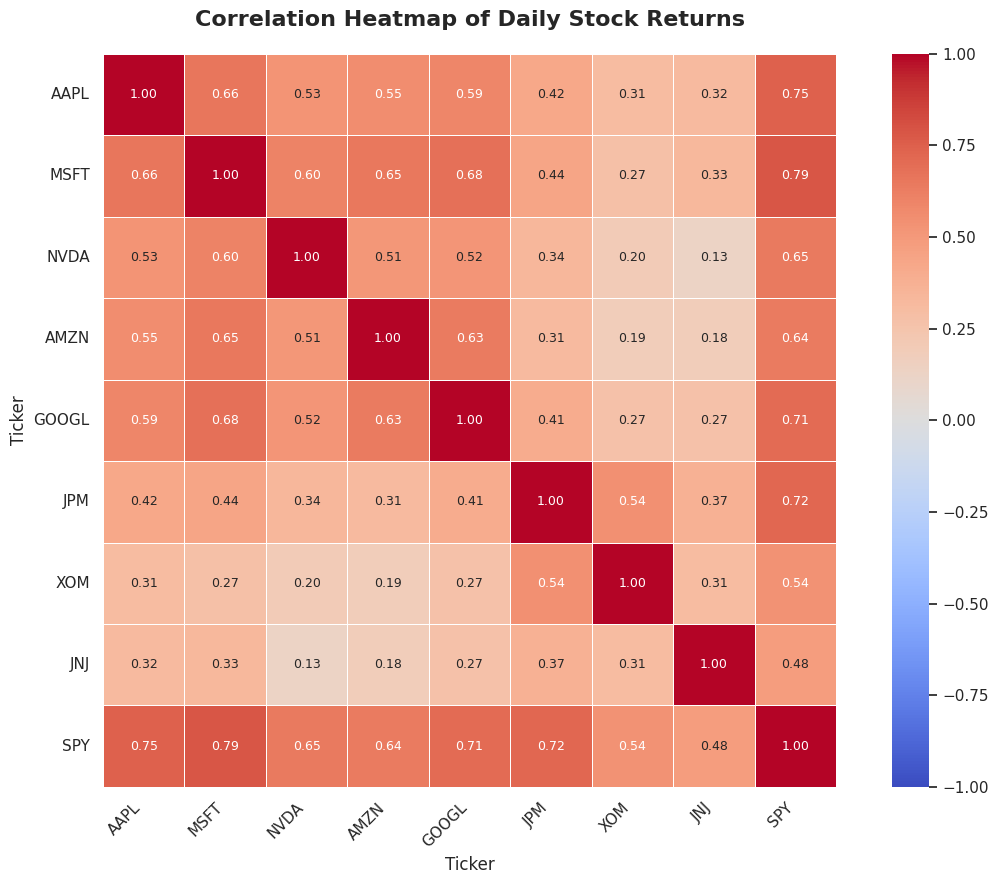

In [12]:
# Calculate correlation matrix
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title(
    "Correlation Heatmap of Daily Stock Returns",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
# Summary statistics of daily returns
return_statistics = daily_returns.describe().T

# Convert to percentage
return_statistics = return_statistics * 100

# Count is not a percentage
return_statistics["count"] = daily_returns.count()

display(return_statistics.round(2))

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2765,0.10,1.82,-12.86,-0.73,0.10,1.00,15.33
MSFT,2765,0.10,1.69,-14.74,-0.67,0.10,0.94,14.22
NVDA,2765,0.26,3.07,-18.76,-1.24,0.26,1.77,29.81
AMZN,2765,0.12,2.07,-14.05,-0.88,0.11,1.14,14.13
GOOGL,2765,0.11,1.82,-11.63,-0.77,0.13,1.00,16.26
JPM,2765,0.08,1.71,-14.96,-0.70,0.07,0.89,18.01
XOM,2765,0.04,1.73,-12.22,-0.82,0.03,0.90,12.69
JNJ,2765,0.04,1.15,-10.04,-0.49,0.05,0.60,8.00
SPY,2765,0.06,1.12,-10.94,-0.37,0.06,0.59,10.50
